In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

#A DNEMD Analysis notebook to analyse my own results! These are alanine-scanning dnemd simulations at positions 776, 768, 718, and 861 in EGFRs tyrosine kinase domain.
positions = [776, 768, 718, 861]
columns = ["CA_index", "avg_x", "avg_y", "avg_z", "n_x", "n_y", "n_z", "avg_disp", "se_x", "se_y", "se_z", "se_mag", "sd2_x", "sd2_y", "sd2_z", "sd2_mag"]
numbered_cas = np.arange(694, 1020, 1)

ploop = (numbered_cas >= 715) & (numbered_cas <= 730) #Structures of interest can be applied as filters when a "zoom-in" is desired
achelix  = (numbered_cas >= 740) & (numbered_cas <= 770)
activloop = (numbered_cas >= 855) & (numbered_cas <= 884)
#CLEAN THIS CODE UP LATER!

filename_776 = "776_textfiles/vec_norm_stats_5000_NullP_wt1SD.txt"
filename_768 = "768_textfiles/vec_norm_stats_5000_NullP_wt1SD.txt"
filename_718 = "718_textfiles/vec_norm_stats_5000_NullP_wt1SD.txt"
filename_861 = "861_textfiles/vec_norm_stats_5000_NullP_wt1SD.txt" #Filenames for the D-NEMD responses after 5 ns

df_776 = pd.read_csv(filename_776, sep='\s+', comment='#', header=None)
df_776.columns = columns
df_776["CA_index"] = df_776["CA_index"] + 693 #Cleaning up the numbering to match publications

df_768 = pd.read_csv(filename_768, sep='\s+', comment='#', header=None)
df_768.columns = columns
df_768["CA_index"] = df_768["CA_index"] + 693

df_718 = pd.read_csv(filename_718, sep='\s+', comment='#', header=None)
df_718.columns = columns
df_718["CA_index"] = df_718["CA_index"] + 693

df_861 = pd.read_csv(filename_861, sep='\s+', comment='#', header=None)
df_861.columns = columns
df_861["CA_index"] = df_861["CA_index"] + 693

In [39]:

print(f"Error in 776 is {df_776['se_mag'].mean():.4f}")
print(f"Error in 768 is {df_768['se_mag'].mean():.4f}")
print(f"Error in 718 is {df_718['se_mag'].mean():.4f}")
print(f"Error in 861 is {df_861['se_mag'].mean():.4f}") 

Error in 776 is 0.0435
Error in 768 is 0.0431
Error in 718 is 0.0429
Error in 861 is 0.0428


<function matplotlib.pyplot.show(close=None, block=None)>

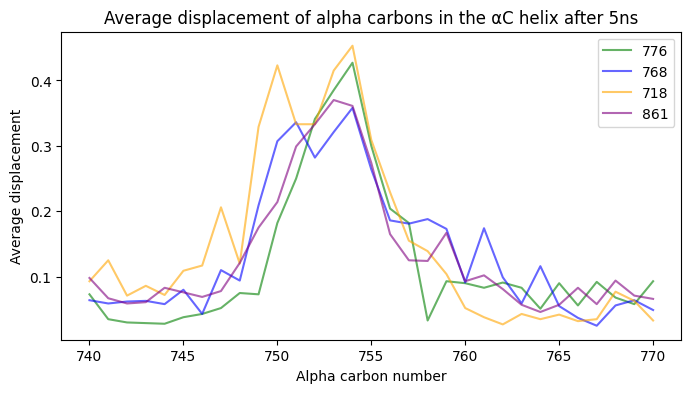

In [40]:
plt.figure(figsize=(8,4))
plt.plot(numbered_cas[achelix], df_776["avg_disp"][achelix], color = "green", alpha = 0.6, label = 776)
plt.plot(numbered_cas[achelix], df_768["avg_disp"][achelix], color = "blue", alpha = 0.6, label = 768 )
plt.plot(numbered_cas[achelix], df_718["avg_disp"][achelix], color = "orange", alpha = 0.6, label = 718)
plt.plot(numbered_cas[achelix], df_861["avg_disp"][achelix], color = "purple", alpha = 0.6, label = 861)
plt.ylabel("Average displacement")
plt.xlabel("Alpha carbon number")
plt.legend(loc=1)
plt.title("Average displacement of alpha carbons in the αC helix after 5ns")

# plt.plot(numbered_cas, df_776["se_mag"], color = "green", alpha = 0.3)
# plt.plot(numbered_cas, df_768["se_mag"], color = "blue", alpha = 0.3)
# plt.plot(numbered_cas, df_718["se_mag"], color = "orange", alpha = 0.3)
# plt.plot(numbered_cas, df_861["se_mag"], color = "purple", alpha = 0.3)

plt.show

Text(0.5, 1.0, 'Average displacement of alpha carbons in the activation loop after 5ns')

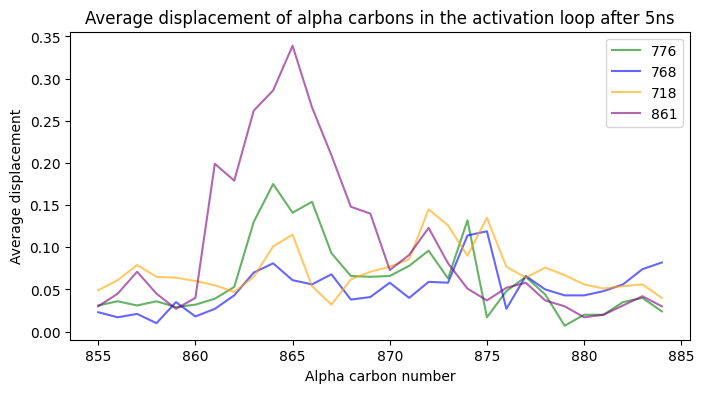

In [41]:
plt.figure(figsize=(8,4))
plt.plot(numbered_cas[activloop], df_776["avg_disp"][activloop], color = "green", alpha = 0.6, label = 776)
plt.plot(numbered_cas[activloop], df_768["avg_disp"][activloop], color = "blue", alpha = 0.6, label = 768 )
plt.plot(numbered_cas[activloop], df_718["avg_disp"][activloop], color = "orange", alpha = 0.6, label = 718)
plt.plot(numbered_cas[activloop], df_861["avg_disp"][activloop], color = "purple", alpha = 0.6, label = 861)
plt.ylabel("Average displacement")
plt.xlabel("Alpha carbon number")
plt.legend(loc=1)
plt.title("Average displacement of alpha carbons in the activation loop after 5ns")

Text(0.5, 1.0, 'Average displacement of alpha carbons in the P loop after 5ns')

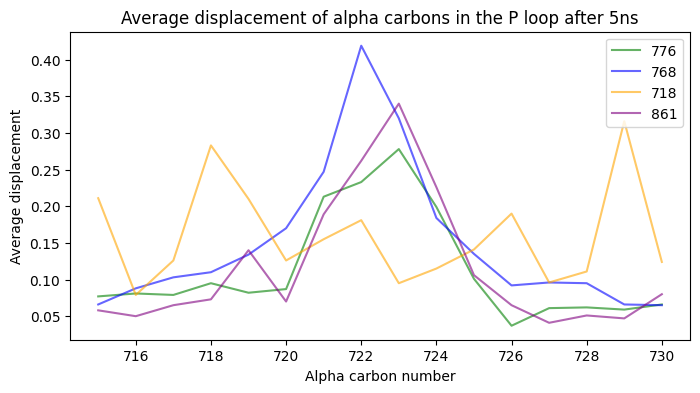

In [42]:
plt.figure(figsize=(8,4))
plt.plot(numbered_cas[ploop], df_776["avg_disp"][ploop], color = "green", alpha = 0.6, label = 776)
plt.plot(numbered_cas[ploop], df_768["avg_disp"][ploop], color = "blue", alpha = 0.6, label = 768 )
plt.plot(numbered_cas[ploop], df_718["avg_disp"][ploop], color = "orange", alpha = 0.6, label = 718)
plt.plot(numbered_cas[ploop], df_861["avg_disp"][ploop], color = "purple", alpha = 0.6, label = 861)
plt.ylabel("Average displacement")
plt.xlabel("Alpha carbon number")
plt.legend(loc=1)
plt.title("Average displacement of alpha carbons in the P loop after 5ns")

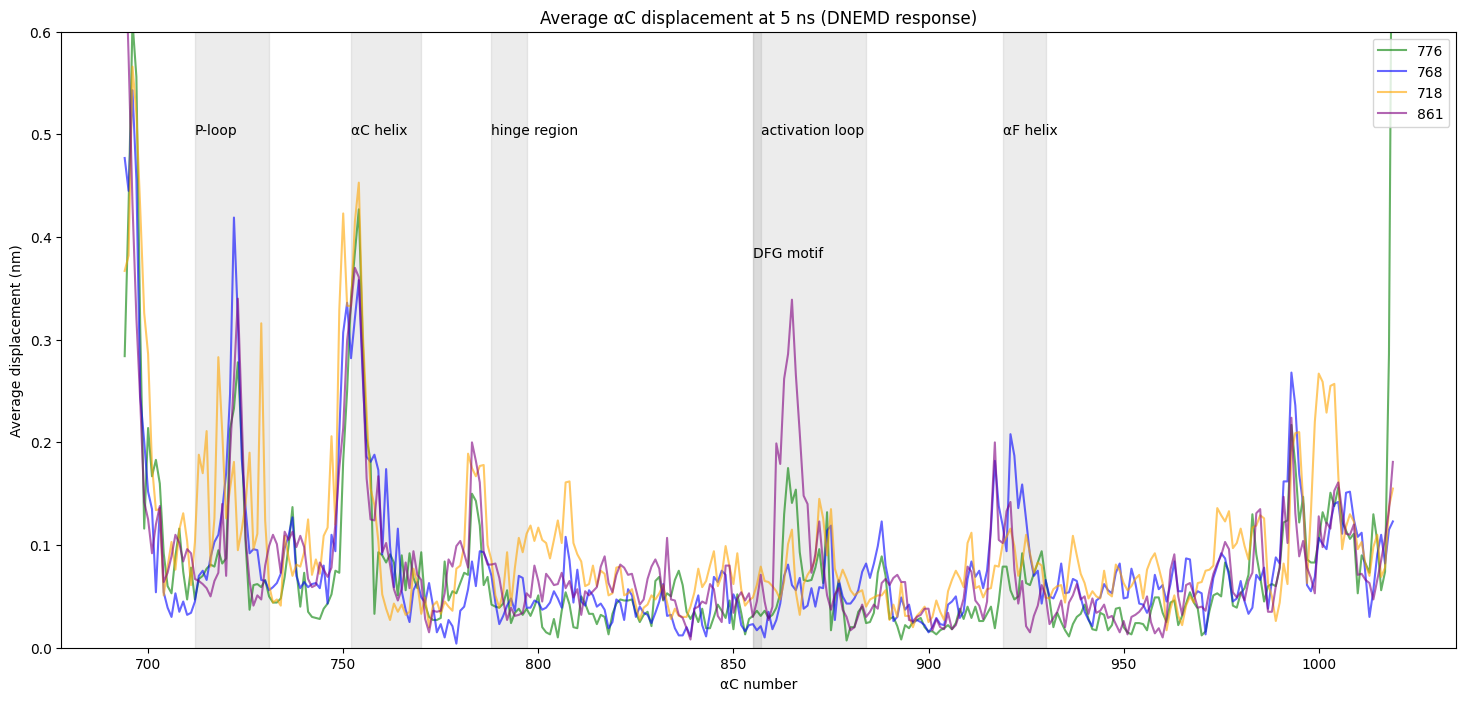

In [ ]:
#Large plot to compare each of the rmsfs to eeachother

plt.figure(figsize=(18,8))


plt.plot(numbered_cas, df_776["avg_disp"], color = "green", alpha = 0.6, label = 776)
plt.plot(numbered_cas, df_768["avg_disp"], color = "blue", alpha = 0.6, label = 768)
plt.plot(numbered_cas, df_718["avg_disp"], color = "orange", alpha = 0.6, label = 718)
plt.plot(numbered_cas, df_861["avg_disp"], color = "purple", alpha = 0.6, label = 861)
plt.xlabel("αC number")
plt.ylabel("Average displacement (nm)")
plt.title("Average αC displacement at 5 ns (DNEMD response)")
plt.legend(loc=1)
plt.ylim(0, 0.6)
#plt.savefig("frame0001")

ax = plt.gca()
ax.axvspan(712, 731, alpha=0.15, color="grey", zorder=0)
ax.text(712, 0.5, "P-loop" )

ax.axvspan(752, 770, alpha=0.15, color="grey", zorder=0)
ax.text(752, 0.5, "αC helix" )

ax.axvspan(855, 884, alpha=0.15, color="grey", zorder=0)
ax.text(857, 0.5, "activation loop" )

ax.axvspan(788, 797, alpha=0.15, color="grey", zorder=0)
ax.text(788, 0.5, "hinge region")

ax.axvspan(855, 857, alpha=0.15, color="grey", zorder=0)
ax.text(855, 0.38, "DFG motif")

ax.axvspan(919, 930, alpha=0.15, color="grey", zorder=0)
ax.text(919, 0.5, "αF helix")
#plt.savefig("Overlaymutations.png")
plt.show()

#CAn do this parallel so that error bars can be added without being nonsense

In [ ]:
def add_regions(ax):
    ax.axvspan(712, 731, alpha=0.15, color="grey", zorder=0)
    ax.text(712, 0.6, "P-loop", alpha = 0.7, fontsize = 8)

    ax.axvspan(752, 770, alpha=0.15, color="grey", zorder=0)
    ax.text(752, 0.6, "αC helix", alpha = 0.7, fontsize = 8)

    ax.axvspan(855, 884, alpha=0.15, color="grey", zorder=0)
    ax.text(857, 0.6, "activation loop", alpha = 0.7, fontsize = 8)

    ax.axvspan(788, 797, alpha=0.15, color="grey", zorder=0)
    ax.text(788, 0.5, "hinge region", alpha = 0.7, fontsize = 8)

    ax.axvspan(855, 857, alpha=0.15, color="grey", zorder=0)
    ax.text(855, 0.4, "DFG motif", alpha = 0.7, fontsize = 8)

    ax.axvspan(919, 930, alpha=0.15, color="grey", zorder=0)
    ax.text(919, 0.7, "αG helix", alpha = 0.7, fontsize = 8)

    ax.axvspan(894, 909, alpha=0.15, color="grey", zorder=0)
    ax.text(894, 0.5, "αF helix", alpha = 0.7, fontsize = 8) #Making addding labels slightly less tedious when plotting and editing a 4x4 grid of plots

def add_axlabels(ax):
    ax.set_ylabel("Average displacement ( Å )")
    ax.set_xlabel("Cα number")


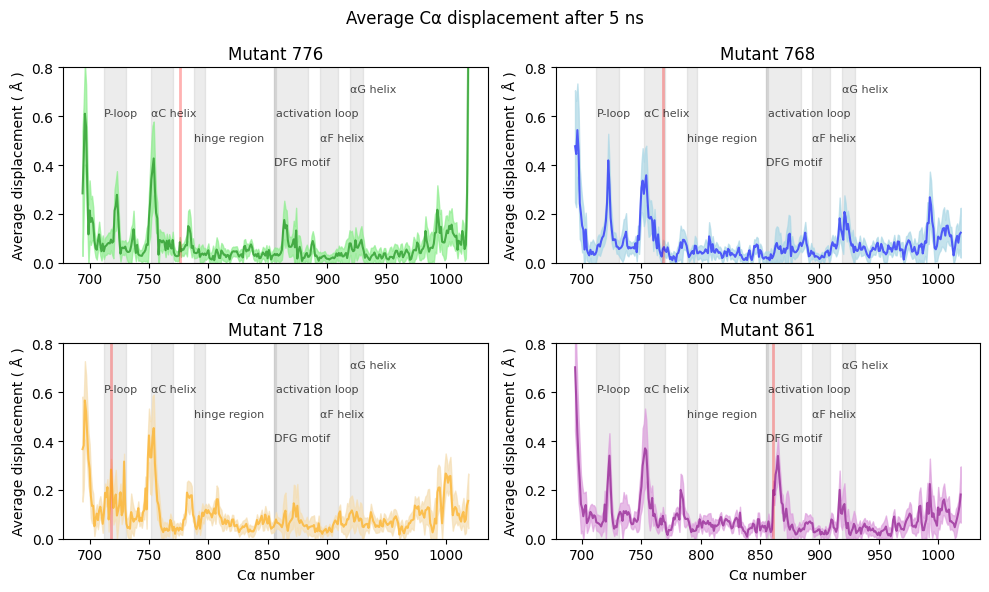

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(10, 6))

#766 
axs[0,0].axvline(x=776, linewidth=2, color="red", alpha = 0.3)
axs[0, 0].plot(numbered_cas, df_776["avg_disp"], color="green", alpha=0.6)
axs[0, 0].fill_between(
    numbered_cas,
    df_776["avg_disp"] - df_776["se_mag"],
    df_776["avg_disp"] + df_776["se_mag"],
    alpha=0.7,
    color="lightgreen"
)

axs[0, 0].set_title("Mutant 776")
axs[0, 0].set_ylim(0, 0.8)

#768
axs[0,1].axvline(x=768, linewidth=2, color="red", alpha = 0.3)
axs[0, 1].plot(numbered_cas, df_768["avg_disp"], color="blue", alpha=0.6)
axs[0, 1].fill_between(
    numbered_cas,
    df_768["avg_disp"] - df_768["se_mag"],
    df_768["avg_disp"] + df_768["se_mag"],
    alpha=0.7,
    color="lightblue"
)

axs[0, 1].set_title("Mutant 768")
axs[0, 1].set_ylim(0, 0.8)

#718
axs[1,0].axvline(x=718, linewidth=2, color="red", alpha = 0.3)
axs[1, 0].plot(numbered_cas, df_718["avg_disp"], color="orange", alpha=0.6)
axs[1, 0].fill_between(
    numbered_cas,
    df_718["avg_disp"] - df_718["se_mag"],
    df_718["avg_disp"] + df_718["se_mag"],
    alpha=0.7,
    color="wheat"
)

axs[1, 0].set_title("Mutant 718")
axs[1, 0].set_ylim(0, 0.8)

#861
axs[1,1].axvline(x=861, linewidth=2, color="red", alpha = 0.3)
axs[1, 1].plot(numbered_cas, df_861["avg_disp"], color="purple", alpha=0.6)
axs[1, 1].fill_between(
    numbered_cas,
    df_861["avg_disp"] - df_861["se_mag"],
    df_861["avg_disp"] + df_861["se_mag"],
    alpha=0.7,
    color="plum"
)

axs[1, 1].set_title("Mutant 861")
axs[1, 1].set_ylim(0, 0.8)

fig.suptitle("Average Cα displacement after 5 ns")
for ax in axs.flat:
    add_regions(ax)
for ax in axs.flat:
    add_axlabels(ax)


plt.tight_layout()
plt.savefig("Mutantdisplacements.png")
plt.show()

